# Data Challenge: Python, arrays and plotting

In this python notebook you are going to read in and plot some data.

**Learning Objectives:** Understand how to make simple plots.

## 1. Making Simple Plots with Matplotlib: Scatter and Line Plots

We're going to inspect the data by plotting the data and variables against each other. Matplotlib is *the* python plotting library. You can plot data in a huge variety of ways. Very useful examples of the kind of things matplotlib can do can be found here (see tutorials and gallery): https://matplotlib.org/index.html. **Also see Chapter 8 in BG.**

We're going to start with a basic plot.

In [2]:
#Lets start by loading our required modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  #plt is an oft-used shorthand for matplotlib.pyplot, much like np for numpy

Next we will read in our table.  In my example I'll use astropy tables.  I prefer this as I can do operations (like np.where) on the table columns directly, as if they were arrays.  To directly convert a column to an array, I could do:
a=tab['col1'].data

If you wanted to operate on a PANDAS column, you would need to do:
a=np.array(df['col1'])

In [3]:
#Now lets read in the same data table from last class
from astropy.io import ascii
tab=ascii.read('Finkelstein24_data.csv',format='csv')
tab  #Showing the table to remind myself what it looks like

id,ra,dec,m277,int_zgt7,photz,photzerr_hi,photzerr_low,chia,dchi2,sample,specz,M1500,M1500err_hi,M1500err_low,rh_200,rh_277
str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64
CEERS-1398,214.937205,52.965351,29.2,0.96,9.01,0.27,1.53,17.0,4.3,9,-1.0,-17.3,1.42,0.25,1.22,1.84
CEERS-2067,215.010026,53.013641,27.8,1.0,12.7,0.99,0.72,15.6,8.3,14,-1.0,-20.09,0.2,0.03,3.53,3.26
CEERS-4702,214.994404,52.989378,27.5,1.0,8.98,0.12,0.12,2.9,22.0,9,8.809,-20.17,0.09,0.03,1.75,2.09
CEERS-5007,214.966722,52.968284,28.5,0.96,8.98,0.27,0.36,7.4,6.7,9,-1.0,-19.21,0.23,0.12,1.85,2.13
CEERS-6184,214.950081,52.949266,28.0,1.0,8.92,0.03,0.57,19.4,14.3,9,-1.0,-19.49,0.29,0.02,1.92,2.28
CEERS-7078,215.011708,52.988303,27.1,1.0,8.98,0.06,0.06,25.4,75.9,9,8.876,-20.44,-0.0,0.14,2.28,2.55
CEERS-10332,215.044001,52.994302,28.4,1.0,10.57,0.18,1.05,6.7,14.3,10,-1.0,-19.49,0.42,0.08,4.13,4.68
CEERS-10545,214.997038,52.960082,28.2,0.99,8.89,0.06,0.3,16.1,6.6,9,-1.0,-19.64,0.14,0.04,1.43,1.6
CEERS-11384,214.90664,52.945504,27.5,1.0,11.53,0.3,0.3,7.1,11.2,11,11.043,-20.02,0.07,0.15,1.5,1.77


Basic plotting of 2-dimensional data can be done with <code>plt.plot</code>. <br>
The syntax for <code>plt.plot</code> is: 
```python
plt.plot(x, y, kwargs)
```   
where `kwargs` are the keyword arguments, or the customization options, for your plot. <br>
Some of the customizations include: <br>

    markerstyle - 'o' (circles), '^' (triangles), '*' (stars), '.' (small points), etc. 
    linestyle - '-' (you solid line), '--' (dotted line), ':' (fine dotted line), etc. 
    color - standard colors: 'b', 'r', 'c', 'm', 'k', hexcode: '#XXXXXX', html colors 
    alpha - opacity, a float between 0 and 1
    label- name used in the legend 

<div class="alert alert-block alert-warning">
<b>Note: </b> 
    Every keyword argument besides alpha should be given as a string.
</div>

In [4]:
#I'd like to plot galaxy fluxes versus their photometric redshift. The table has the latter ('photz')
#For the former, I need to calculate it from the magnitude ('m277')
flux=10.0**(-0.4*(tab['m277']+48.6))  #This converts the magnitude (in AB magnitudes) to flux (in erg/s/cm**2/Hz)
flux_njy=np.array(flux)*1.0e32  #Lets convert to nJy to have some more friendly numbers, and print the array to confirm this
flux_njy

array([  7.58577575,  27.54228703,  36.30780548,  14.45439771,
        22.90867653,  52.48074602,  15.84893192,  19.05460718,
        36.30780548,   8.31763771,  15.84893192,  15.84893192,
        19.05460718,  83.17637711,  25.11886432,  14.45439771,
        14.45439771,   8.31763771,  39.81071706,  17.37800829,
        14.45439771,   8.31763771,  14.45439771,  17.37800829,
        22.90867653,  15.84893192,  15.84893192,  30.1995172 ,
        19.05460718,  22.90867653,  25.11886432,  17.37800829,
       109.64781961,  69.18309709,  63.09573445,  57.54399373,
        10.96478196,  12.02264435,  19.05460718,  10.96478196,
         9.12010839,  30.1995172 ,  12.02264435,  17.37800829,
        19.05460718,  14.45439771,  20.89296131,   7.58577575,
        10.        ,  10.96478196,  10.        ,  43.65158322,
        13.18256739,  13.18256739,  43.65158322,  20.89296131,
        19.05460718,  17.37800829,  14.45439771,  19.05460718,
        25.11886432,   9.12010839,  33.11311215,  27.54

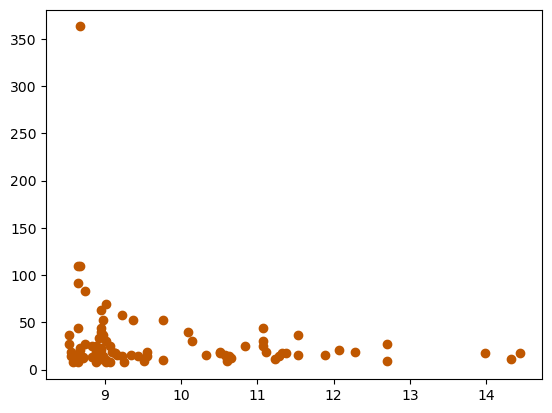

In [14]:
#Lets plot the source flux versus the photometric redshift
plt.plot(tab['photz'],flux_njy,'o',color=(191./255.,87./255.,0)) # This is the most basic default scatter plot you can make
plt.show()

Clearly this is not a great plot from an information or visualization/design perspective! 

<font color='green'> Take a look at the matplotlib pyplot capabilities here: https://matplotlib.org/stable/api/pyplot_summary.html#module-matplotlib.pyplot 
    Modify the code to improve the following:</font>

1. Add a title and axis labels: title(), xlabel(), ylabel() (make sure they and the axis tick marks are large enough to read).

2. The data is concentrated in the bottom of the plot; you can fix this by making the axes scale logarithmic, with, for example plt.yscale('log').  Or, if you want both axes logarithmic, you can change plot() to loglog().  

3. Matplotlib usually does a good job of automatically seting the x/y axis range, but you can also set this yourself: xlim(), ylim() Set the range manually to values that let you best visualize all of the data.

4. Add a line showing a rough minimum flux (this would be our detection limit) as a function of redshift. This requires making a new arrays and populating them with values for flux and redshift.

5. Add a legend that defines the line and points: legend() (Make sure it is not blocking any of the data).

6. Add error bars to the redshift (the table provides both an upper and lower error value)


In [ ]:
#Lets plot the source flux versus the photometric redshift


Bonus: Make any points with spectroscopic redshifts (tab['specz'] > 0) a different point type and color from those below, and add to the legend

In [ ]:
#Bonus plot


Now that you have created your data-work-of-art of course you want to save it for posterity! You can use the savefig() command (e.g. S8.8 in BG). 

<font color='green'> Research the savefig() keyword options.  Save your plot to both png and jpg file formats. Experiment with different pixel resolution (keyword dpi). The keyword bbox_inches=’tight’ can also be useful to make sure these no extra whitespace around your figure. </font>

In [ ]:
#Save your plot - copy the code from the above cell, and add plt.savefig(options) prior to plt.show


## 2. Making Simple Plots with Matplotlib: Histograms

What if you don't want to see how one variable relates to another, what if you want to look at the distribution of a single variable? If this is the case you might make a histogram plot, using the matplotlib hist() function.

<font color='green'> Make a histogram of the redshift.  First create a new variable for redshift using spectroscopic redshifts when available, and photo-z otherwise. Use the best plotting practices we learned above. Inspect the impact of the bin size on the plot. What is the best way to display the data? What does the plot tell you about the data? </font>

In [ ]:
# Your code here
#help(plt.hist)
